Diogo Viveiros
## Imports

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from mlxtend.plotting import heatmap

## Data Ingestion

In [2]:
train = pd.read_csv("vol_dataset_train_20150102_20221230.csv")
test = pd.read_csv("vol_dataset_test_20250102_20251231.csv")
val = pd.read_csv("vol_dataset_validation_20230103_20241231.csv")

C:\Users\Diogo\AppData\Local\Temp\ipykernel_35168\3680254594.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("vol_dataset_train_20150102_20221230.csv")
C:\Users\Diogo\AppData\Local\Temp\ipykernel_35168\3680254594.py:3: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  val = pd.read_csv("vol_dataset_validation_20230103_20241231.csv")


In [3]:
#Sort all of the values by date and get only the features we need for both the V1 and the V2 models. 
train = train.sort_values(by='date')[['date','ticker', 'y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX', 'forward_vol_5d_annual_decimel_calculated']].dropna()
test = test.sort_values(by='date')[['date','ticker','y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX', 'forward_vol_5d_annual_decimel_calculated' ]].dropna()
val = val.sort_values(by='date')[['date','ticker','y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX', 'forward_vol_5d_annual_decimel_calculated' ]].dropna()

#Set the indices to the dates, and ensure that they're in DateTime format 
train = train.set_index('date')
train.index = pd.to_datetime(train.index)
test = test.set_index('date')
test.index = pd.to_datetime(test.index)
val = val.set_index('date')
val.index = pd.to_datetime(val.index)

## Basic Dataframe Check

In [4]:
train

,ticker,y_known_at_t,trailing_vol_annual_decimel_20d_calculated,volume,NYGOLDS,OIL_WTI_S,US_10Y_BOND_YLD,US_3M_TB_YLD,VIX,forward_vol_5d_annual_decimel_calculated
date,,,,,,,,,,
2015-01-30,KCE,0.2096,0.2250,2009,1283.1,47.79,1.65,0.02,20.97,0.1612
2015-01-30,XSD,0.1886,0.2337,59744,1283.1,47.79,1.65,0.02,20.97,0.1564
2015-01-30,XLE,0.3424,0.3042,87696260,1283.1,47.79,1.65,0.02,20.97,0.3086
2015-01-30,XTL,0.0580,0.1468,9778,1283.1,47.79,1.65,0.02,20.97,0.2365
2015-01-30,IYZ,0.1214,0.1583,147895,1283.1,47.79,1.65,0.02,20.97,0.1725
...,...,...,...,...,...,...,...,...,...,...
2022-12-30,XES,0.4557,0.4446,82419,1824.5,80.16,3.88,4.41,21.67,0.5685
2022-12-30,XHB,0.2616,0.2257,1921194,1824.5,80.16,3.88,4.41,21.67,0.2222
2022-12-30,XHE,0.2591,0.2255,34277,1824.5,80.16,3.88,4.41,21.67,0.2212


## Plot Heatmap

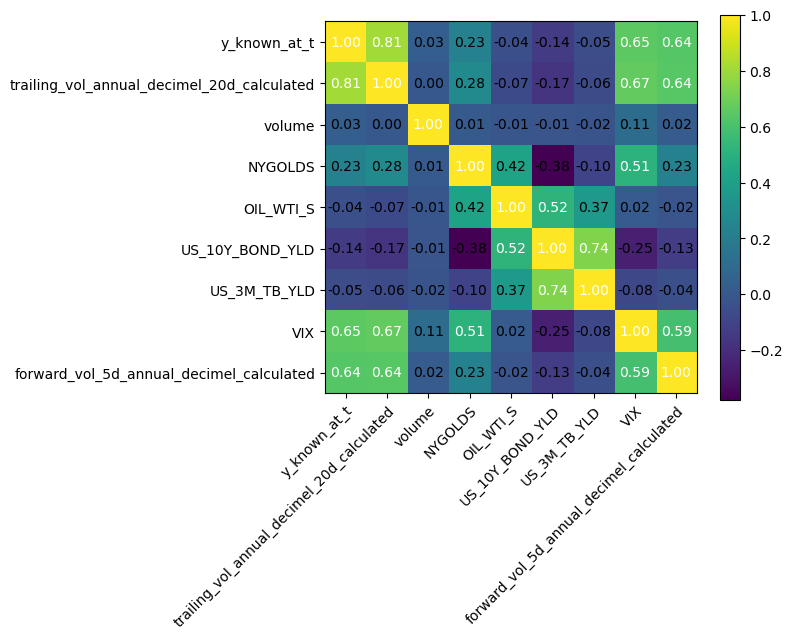

In [27]:
#Plot heatmap and render plot
cm = train[['y_known_at_t', 'trailing_vol_annual_decimel_20d_calculated', 'volume', 'NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX', 'forward_vol_5d_annual_decimel_calculated']].copy()
cm = cm.corr()

hm = heatmap(
    cm.values,
    row_names=cm.index,
    column_names=cm.columns,
    figsize=(6,5)
)
plt.show()

## Plot Graph showing Volatility over time and showcasing COVID Impact

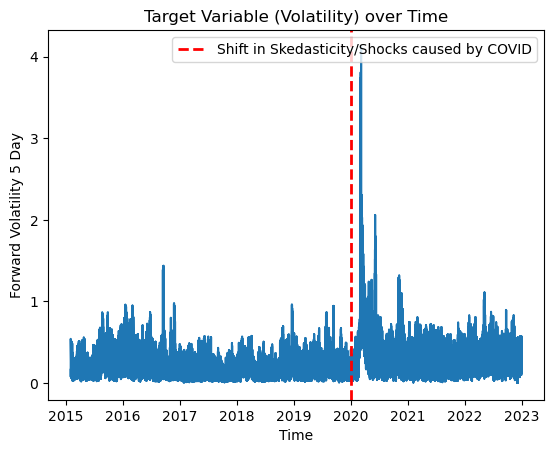

In [23]:
plt.plot(train['forward_vol_5d_annual_decimel_calculated'])
plt.ylabel("Forward Volatility 5 Day")
plt.xlabel("Time")
plt.title("Target Variable (Volatility) over Time")
plt.axvline(pd.to_datetime('2020-01-01'), color='red', linestyle='--', linewidth=2, 
            label='Shift in Skedasticity/Shocks caused by COVID')
plt.legend()